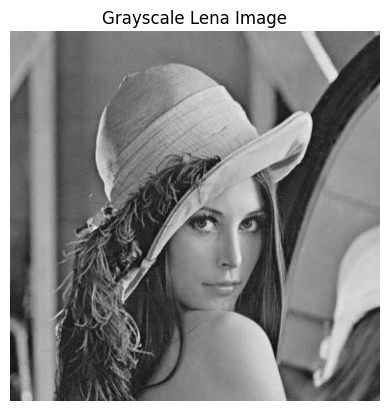

Original shape: (512, 512)
Batch shape: (1, 512, 512, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 498, 498, 1)    │           226 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226 (904.00 B)

 Trainable params: 226 (904.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
Convolution output shape: (1, 498, 498, 1)
[[-5.4697357e+01 -5.4864681e+01 -5.3489334e+01 ... -1.9120304e+01
  -1.3650725e+01 -1.7250896e+01]
 [-5.5056282e+01 -5.5132767e+01 -5.4027222e+01 ... -1.2608791e+01
  -5.3653469e+00 -3.9659767e+00]
 [-5.5558651e+01 -5.4399651e+01 -5.3311691e+01 ... -4.9664249e+00
   1.6397476e-02  6.1848564e+00]
 ...
 [-2.0472633e+01 -2.1434380e+01 -2.2135941e+01 ... -2.8041172e+01
  -3.1367289e+01 -3.4171669e+01]
 [-2.1876778e+01 -1.7596207e+01 -1.6720440e+01 ... -3.0523685e+01
  -2.8793213e+01 -2.9963469e+01]
 [-1.9814724e+01 -1.4044277e+01 -1.2548761e+01 ... -3.2932064e+01
  -2.7529022e+01 -2.8003946e+01]]


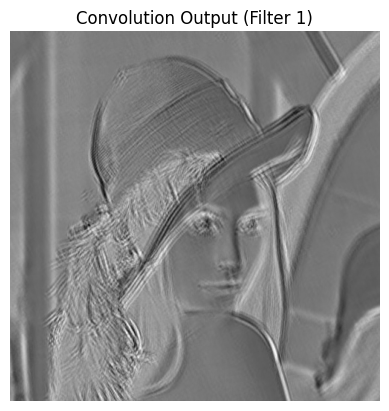

In [2]:
#https://www.youtube.com/watch?v=S5MwKyYYLSM
from keras.layers import Convolution2D, MaxPooling2D, Activation
from keras.models import Sequential
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 1. Read an image in grayscale
img = cv2.imread('/content/sample_data/lena.jpg', cv2.IMREAD_GRAYSCALE)

# 2. Display the image
plt.imshow(img, cmap='gray')
plt.title("Grayscale Lena Image")
plt.axis("off")
plt.show()

# 3. Check shape
print("Original shape:", img.shape)   # (512, 512)

# 4. Reshape to batch format for Keras (batch_size=1, height, width, channels)
img_batch = img.reshape(1, img.shape[0], img.shape[1], 1)
print("Batch shape:", img_batch.shape)  # (1, 512, 512, 1)
input_shape = img_batch.shape[1:]
# Define a simple CNN model
model1 = Sequential()
model1.add(Convolution2D(
    filters=1,              # number of filters
    kernel_size=(15, 15),   # filter size
    padding='valid',        # no padding
    input_shape=input_shape # shape of input image
))

# Show model summary
model1.summary()

# Forward pass through the first model
conv_img = model1.predict(img_batch)
print("Convolution output shape:", conv_img.shape)   # (1, 498, 498, 10)

# Reshape one feature map for visualization
conv_img_show = conv_img.reshape(conv_img.shape[1], conv_img.shape[2])
print(conv_img_show)

plt.imshow(conv_img_show, cmap='gray')
plt.title("Convolution Output (Filter 1)")
plt.axis("off")
plt.show()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 498, 498, 1)    │           226 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 498, 498, 1)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226 (904.00 B)

 Trainable params: 226 (904.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
Conv+ReLU output shape: (1, 498, 498, 1)


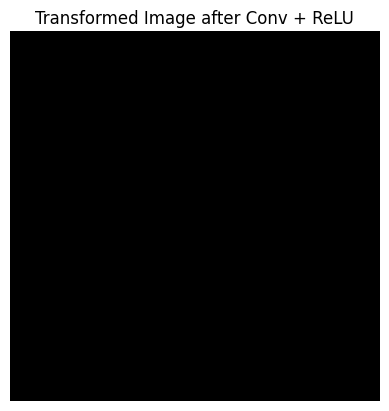

In [3]:
# Define a second model with ReLU activation
model2 = Sequential()
model2.add(Convolution2D(
    filters=1,
    kernel_size=(15,15),
    padding='valid',
    input_shape=img_batch.shape[1:]
))
model2.add(Activation('relu'))

# Show summary
model2.summary()

# Forward pass through model2 (Conv2D + ReLU)
conv_img = model2.predict(img_batch)
print("Conv+ReLU output shape:", conv_img.shape)   # e.g. (1, 498, 498, 1)

# Reshape to 2D for visualization
conv_img_show = conv_img.reshape(conv_img.shape[1], conv_img.shape[2])

# Display the transformed image
plt.imshow(conv_img_show, cmap='gray')
plt.title("Transformed Image after Conv + ReLU")
plt.axis("off")
plt.show()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 498, 498, 1)    │           226 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 498, 498, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 249, 249, 1)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226 (904.00 B)

 Trainable params: 226 (904.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Conv+ReLU+Pooling output shape: (1, 249, 249, 1)


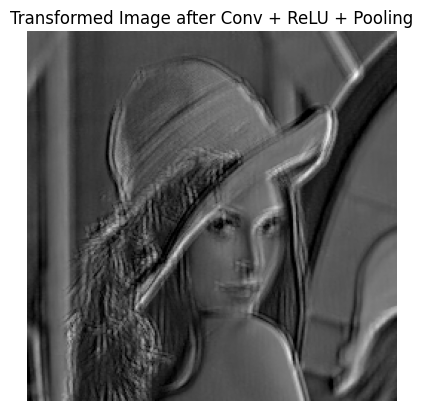

In [4]:
# Define CNN model with Conv + ReLU + MaxPooling
model4 = Sequential()
model4.add(Convolution2D(
    filters=1,
    kernel_size=(15,15),
    padding='valid',
    input_shape=img_batch.shape[1:]   # (512, 512, 1)
))  # random weight initialization
model4.add(Activation('relu'))
model4.add(MaxPooling2D(pool_size=(2,2)))

# Show model summary
model4.summary()

# Forward pass through the model
conv_img = model4.predict(img_batch)
print("Conv+ReLU+Pooling output shape:", conv_img.shape)

# Reshape to 2D for visualization
conv_img_show = conv_img.reshape(conv_img.shape[1], conv_img.shape[2])

# Display the transformed image
plt.imshow(conv_img_show, cmap='gray')
plt.title("Transformed Image after Conv + ReLU + Pooling")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Custom filter output shape: (1, 510, 510, 1)


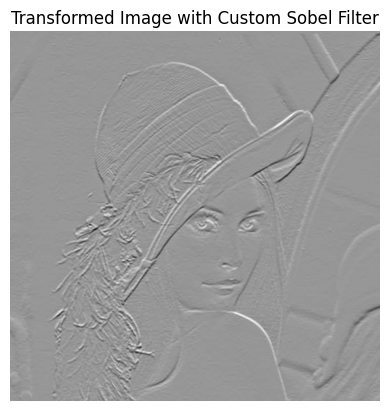

In [7]:
# Define a simple CNN model
from numpy import asarray
# Define CNN model
model5 = Sequential()
model5.add(Convolution2D(
    filters=1,
    kernel_size=(3,3),
    input_shape=img_batch.shape[1:]
))

# Define Sobel filter for vertical edges
detector_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype='float32')

# Reshape to (3,3,1,1) → (height, width, in_channels, out_channels)
detector_y = detector_y.reshape((3,3,1,1))

# Keras expects [kernel, bias]
weights = [detector_y, np.array([0.], dtype='float32')]

# Set custom weights
model5.set_weights(weights)

# Forward pass
conv_img = model5.predict(img_batch)
print("Custom filter output shape:", conv_img.shape)

# Reshape for visualization
conv_img_show = conv_img.reshape(conv_img.shape[1], conv_img.shape[2])

# Display the transformed image
plt.imshow(conv_img_show, cmap='gray')
plt.title("Transformed Image with Custom Sobel Filter")
plt.axis("off")
plt.show()